# **Pairs Trading Strategy (IT Pair)**
We will try to implement a pairs trading strategy using regression, rolling regression and Kalman Filter. We will be comparing the result of all the models to see which one performed the best our of 3.

Our base equation looks like $$
z_t = y_{1t} - \beta y_{2t} = \mu + \varepsilon_t
$$

$\beta$ is also called as Hedge ratio


## Pair Selection

The theory for pairs trading is covered in theory notes but the whole idea is that first we have to select a pair that is cointegreated in nature. Cointegration means that the stocks individually are not stationary but at some linear combination they form a stationary pair. If we find such a stationary pair we can use statistical analysis to find parameters and form a mean reverting strategy.

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression

We will take TCS and infosys as an example since they both come from IT sector and will mostly move together to form a pair.

In [3]:
start = '2018-01-01'
end = '2024-12-31'

infy = yf.download("INFY.NS",start = start, end = end)['Close']
tcs = yf.download("TCS.NS",start = start, end = end)['Close']


/tmp/ipython-input-2139671675.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  infy = yf.download("INFY.NS",start = start, end = end)['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2139671675.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tcs = yf.download("TCS.NS",start = start, end = end)['Close']
[*********************100%***********************]  1 of 1 completed


In [4]:
adf_result_infy = adfuller(infy)
adf_result_tcs = adfuller(tcs)
print('p_value',adf_result_infy[1])
print('p_value',adf_result_tcs[1])

p_value 0.8313573668561398
p_value 0.6615779339012033


From the above we can see that both infosys and TCS are not stationary individually and now we will test whether their linear pair is stationary or not

In [5]:
df = pd.concat([infy,tcs],axis = 1).dropna()
df.columns = ['Infosys','TCS']
df

,Infosys,TCS
Date,,
2018-01-01,429.768433,1176.522949
2018-01-02,428.167511,1170.119263
2018-01-03,424.674713,1173.432373
2018-01-04,422.221344,1181.637207
2018-01-05,420.807495,1195.912354
...,...,...
2024-12-23,1897.600586,4097.958984
2024-12-24,1882.562134,4118.851562
2024-12-26,1880.935059,4108.602539


Our Equation looks like
$$
y_{1t} = \mu + \beta y_{2t} + \varepsilon_t
$$

We will regress Infosys on TCS using OLS to find out $\varepsilon_t$ which is essentially our spread i.e $Z_t$. We will then run ADF test on residual to find out whether the pair is stationary or not Since our residual is essentially the $Z_t$.

We will regress Infosys on TCS i.e $X_t$ will be TCS and $Y_t$ will be infosys.

In [6]:
X = sm.add_constant(df['TCS'])
#Using OLS for regression we get
model = sm.OLS(df['Infosys'],X).fit()

print(model.summary())

df['Residuals'] = model.resid

                            OLS Regression Results                            
Dep. Variable:                Infosys   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                 3.305e+04
Date:                Wed, 06 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:33:06   Log-Likelihood:                -10364.
No. Observations:                1726   AIC:                         2.073e+04
Df Residuals:                    1724   BIC:                         2.074e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -278.4797      8.023    -34.709      0.0

The last section of the result tells us about the residuals, Since p value of JB test is 0.184 i.e greater than 0.05 we accept null hypothesis which says our residuals are normally distributed. Therefore our residuals are normally distributed here. Omnibus test is also for normality and it's p value also signifies our residuals are normally distributed. Skewness and kurtosis are also in line.

R Square is significant, F stat and individual p stats are also significant since their p values are less than 0.05

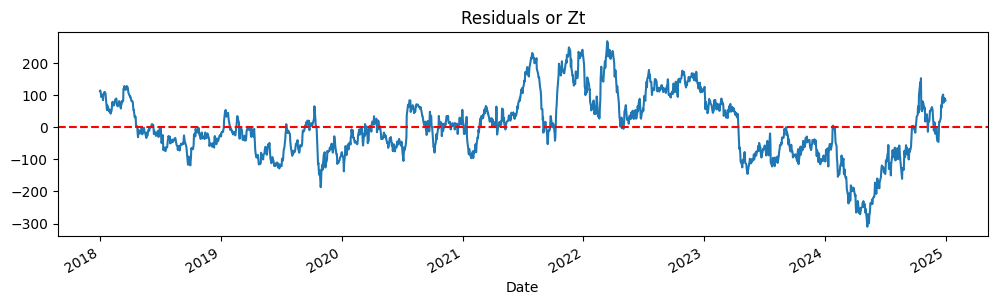

In [7]:
df['Residuals'].plot(figsize=(12,3), title = 'Residuals or Zt')
plt.axhline(0, color='red', linestyle='--')
plt.show()

From the above graph our residuals or $Z_t$ look like stationary we can detect some regime change here as well because the mean reversion speed of the pair was very high till 2021 mid and now the mean reversion speed has reduced that means overall the pairs cointegration has reduced after 2021 mid, let's do ADF test to confirm that

In [8]:
adf_result = adfuller(df['Residuals'])
print('p_value',adf_result[1])

p_value 0.007624593120965014


Since our p value is less than 0.05 that means our adf test confirms that the residuals or $Z_t$ is stationary. Therefore we can move forward and take this as a pair to make a trading strategy out of it.

### Bidirectional Pairs test
We have above regressed Infosys on TCS, we will now regress TCS on infosys to confirm that cointegration exists on the other side as well just to confirm our relationship is not one way dependent

In [9]:
X = sm.add_constant(df['Infosys'])
model = sm.OLS(df['TCS'],X).fit()
print(model.summary())
df['Residuals'] = model.resid


                            OLS Regression Results                            
Dep. Variable:                    TCS   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                 3.305e+04
Date:                Wed, 06 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:33:06   Log-Likelihood:                -11495.
No. Observations:                1726   AIC:                         2.299e+04
Df Residuals:                    1724   BIC:                         2.300e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        659.3635     12.385     53.238      0.0

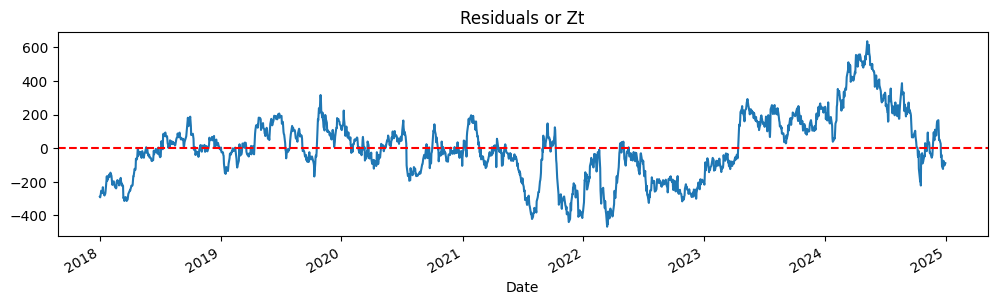

In [10]:
df['Residuals'].plot(figsize=(12,3), title = 'Residuals or Zt')
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [11]:
adf_result = adfuller(df['Residuals'])
print('P-Value',adf_result[1])

P-Value 0.004806683278856404


P value is similar to p value of above pair but slightely less, we will still take primary pair as infosys regressed on TCS as TCS is the larger company and can drive the TCS price more than the other way around

### Correlation between the pairs

Let's find the correlation between the pairs.

In [12]:
correlation = df['Infosys'].corr(df['TCS'])
print(correlation)

0.9748936082059805


The correlation between the two pairs stands at approx 95% that is a strong correlation, let us also find stability of this correlation by taking variance of rolling correlation for 6 months, if Value is less than 0.15 then it means our pair is stable

In [13]:
rolling_corr = df['Infosys'].rolling(126).corr(df['TCS'])
correlation_stability = rolling_corr.std()
print(correlation_stability)

0.24237407619644544


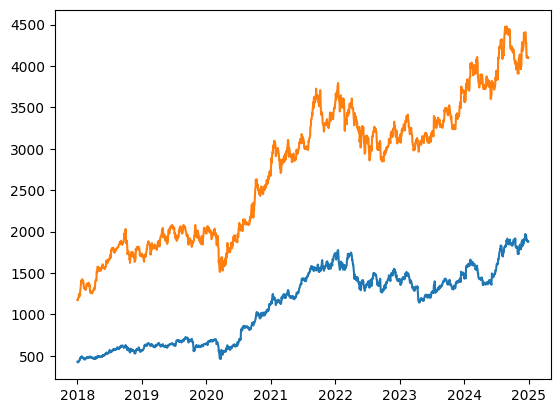

In [14]:
plt.plot(df['Infosys'])
plt.plot(df['TCS'])

From the above visual we can see that the two prices are actually moving in the same direction. It is always a good practice to visualize the two pairs together since it helps us to identify any structural breaks.


## **Static linear Regression**

Now that we have tested our pair and found out that that it is cointegreated and we can use this for our strategy we will first try to estimate the parameters of $\mu$ and $\beta$ using Simple linear regression, here our $\mu$ and $\beta$ will remain static and won't change with time.

Our base line equation is $z_t = y_{1t} - \beta y_{2t} = \mu + \varepsilon_t$
which implies that  $y_{1t} = \beta y_{2t} + \mu + \varepsilon_t$ . Here our $y_{1t}$ is infosys and $y_{2t}$ is infosys. After estimating the parameters we will estimate the residuals because residuals are actual spread we trade on, residuals are calculated as ɛ_t = Actual - predicted values. We will check how our residuals are in all 3 models

In [15]:
df1 = df.drop('Residuals',axis=1)
df1

,Infosys,TCS
Date,,
2018-01-01,429.768433,1176.522949
2018-01-02,428.167511,1170.119263
2018-01-03,424.674713,1173.432373
2018-01-04,422.221344,1181.637207
2018-01-05,420.807495,1195.912354
...,...,...
2024-12-23,1897.600586,4097.958984
2024-12-24,1882.562134,4118.851562
2024-12-26,1880.935059,4108.602539


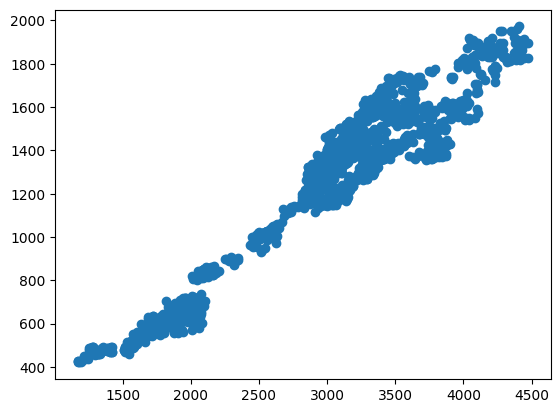

In [16]:
plt.scatter(df1['TCS'],df1['Infosys'])

The above plot is to just check the relationship between two variables

In [17]:
def static_linear_regression(infosys_price,tcs_price):

  #Baseline relationship is Infosys = mu + beta*tcs + et
  x = tcs_price.values.reshape(-1,1) #Converting to 2D array of rows*1 because sklearn wants index and 1 column of labels
  y = infosys_price.values           #Keeping it as 1D array as SKlearn here only wants y labels

  model = LinearRegression()
  model.fit(x,y)

  #Extracting parameters
  mu = model.intercept_
  B = model.coef_[0]

  predicted_infosys = model.predict(x)
  residuals = y - predicted_infosys

  return x,y,mu, B, residuals, model

In [18]:
x,y,mu_SLR, beta_SLR , residuals_SLR, model_SLR = static_linear_regression(df1['Infosys'],df1['TCS'])
print(f'The Average price difference is: {mu_SLR:.2f}')
print(f'The hedge ratio is: {beta_SLR:.4f} (how much Infosys depends on TCS)')
residuals_SLR

The Average price difference is: -278.48
The hedge ratio is: 0.5062 (how much Infosys depends on TCS)


array([112.6635771 , 114.30435732, 109.13438244, ...,  79.54020965,
        90.88073319,  83.297969  ])

Beta Should be positive and less than 0

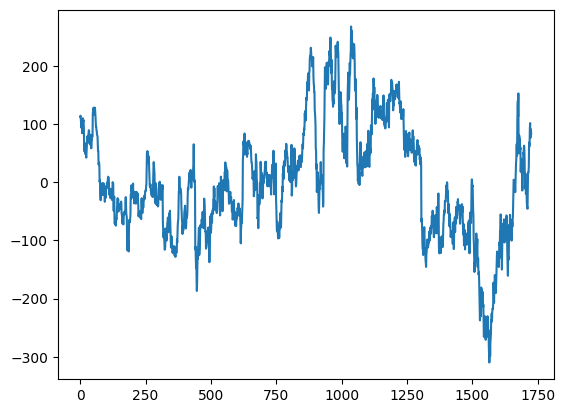

In [19]:
plt.plot(residuals_SLR)

The Residual should ideally be mean reverting and normally distributed. Below we will generate Z scores for trading signals, Our trading strategy will be based on the Z score going above or below SD of 2, however in real life we will often calculate zspreads based on past rolling days data as if we use mean and std of whole residuals then we are incorporting a look ahead bias here

In [20]:
def calculate_zspreads(residual):
  residual = pd.Series(residual)
  zspreads = (residual - residual.rolling(60).mean())/residual.rolling(60).std()
  zspreads = zspreads.fillna(0) #We fill the first 60 days nan values with 0 which just effectively communicates that we are not generating any signal for the first 60 days
  #This is inline with real world as you want the data for last 60 days to start in all the techniques at least, therefore for the initial 60 days you won't take any trade
  return zspreads

In [21]:
zspread_SLR = calculate_zspreads(residuals_SLR)
zspread_SLR

,0
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
...,...
1721,1.473894
1722,0.865648
1723,0.915053
1724,1.134502


The Z spread should ideally be normally distributed and centered around 0 for a healthy mean reverting strategy

(array([  1.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   4.,   1.,   4.,
          2.,   6.,  10.,  16.,  11.,  23.,  22.,  29.,  37.,  52.,  76.,
         83.,  72.,  78.,  76.,  82.,  81., 144.,  64.,  86.,  79.,  75.,
         74.,  65.,  76.,  75.,  55.,  31.,  31.,  28.,  26.,  13.,  13.,
          9.,   5.,   5.,   3.,   0.,   2.]),
 array([-5.40349809e+00, -5.21708588e+00, -5.03067368e+00, -4.84426147e+00,
        -4.65784927e+00, -4.47143706e+00, -4.28502486e+00, -4.09861265e+00,
        -3.91220045e+00, -3.72578825e+00, -3.53937604e+00, -3.35296384e+00,
        -3.16655163e+00, -2.98013943e+00, -2.79372722e+00, -2.60731502e+00,
        -2.42090281e+00, -2.23449061e+00, -2.04807841e+00, -1.86166620e+00,
        -1.67525400e+00, -1.48884179e+00, -1.30242959e+00, -1.11601738e+00,
        -9.29605178e-01, -7.43192974e-01, -5.56780769e-01, -3.70368565e-01,
        -1.83956360e-01,  2.45584434e-03,  1.88868049e-01,  3.75280253e-01,
         5.61692458e-01,  7.48104662e-01,  9.34516

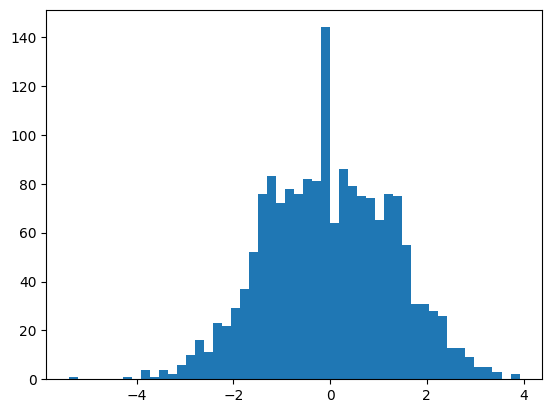

In [22]:
plt.hist(zspread_SLR,bins = 50)

Our Z score looks quite reasonable for real life distribution, there are not very high extreme values. Also deviations of +2 and -2 are also less in frequency because that will be our trading signal

In [23]:
def quality_check(model,x,y,residuals,zspreads):

  #Step 1 checking r square value
  r_squared = model.score(x,y)
  print(f'r_squared value is: {r_squared:.4f}') #Should be greater than 0.7

  #ADF test to check residuals stationarity
  adf_result = adfuller(residuals)
  print('p value of residuals from adf test is',adf_result[1])

  #JB test to check normality of our z spreads
  jb_stat, jb_pvalue = stats.jarque_bera(zspreads)
  print('p value of JB test is',jb_pvalue)

In [24]:
quality_check(model_SLR,x,y,residuals_SLR,zspread_SLR)

r_squared value is: 0.9504
p value of residuals from adf test is 0.007624593120965158
p value of JB test is 0.3165214256334272


R Square value is significant, our residuals p value is around 0.05 therefore we consider this stationary and JB test p value is greater than 0.05 which means our residuals or spreads are normally distributed

## **Rolling Regression**

We will now try to find our parameters using rolling regression strategy and see the results, here we expect both $\mu$ and $\beta$ to dynamically change as they are recalculated everyday for the past 60 days. This strategy is expected to provide in real time info in the market

In [25]:
def rolling_regression_proper(infosys_price, tcs_price, window=60):
    y_data = infosys_price.values
    x_data = tcs_price.values
    dates = infosys_price.index

    mus = []
    betas = []
    residuals = []
    predictions = []
    valid_dates = []

    for i in range(window, len(y_data)):
        # For rolling period of 60 the first iteration of training data will be from index 0 to 59
        train_start = i - window
        train_end = i

        #Below training data starts from index 0 to 59 in the first iteration
        y_train = y_data[train_start:train_end]
        x_train = x_data[train_start:train_end].reshape(-1, 1)

        # Fit model on training data
        model = LinearRegression()
        model.fit(x_train, y_train)

        # Extract parameters
        mu = model.intercept_
        beta = model.coef_[0]

        # Out-of-sample prediction for day i or the day 60th using the mu and beta calculated using days 0 to 59
        prediction = mu + beta * x_data[i]
        residual = y_data[i] - prediction

        # Store results
        mus.append(mu)
        betas.append(beta)
        predictions.append(prediction)
        residuals.append(residual)
        valid_dates.append(dates[i]) #This is important as this stores for which date you are using past 60 days rolling mu and beta

    return {
        'mus': np.array(mus),
        'betas': np.array(betas),
        'residuals': np.array(residuals),
        'predictions': np.array(predictions),
        'dates': pd.DatetimeIndex(valid_dates)
    }

In [26]:
results = rolling_regression_proper(df1['Infosys'],df1['TCS'])

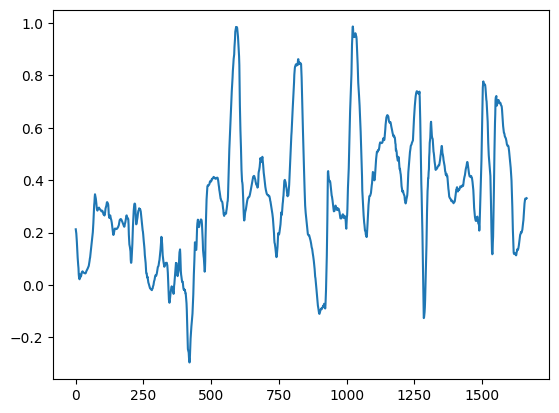

In [27]:
plt.plot(results['betas'])

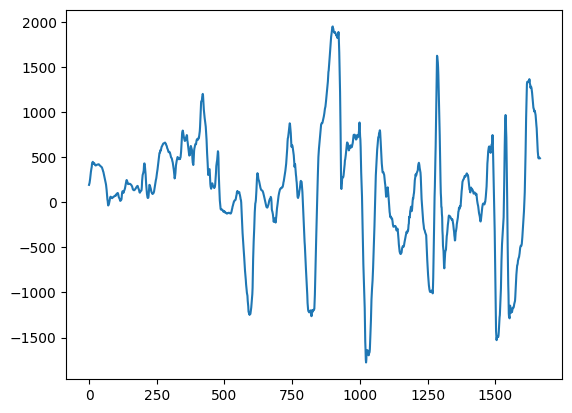

In [28]:
plt.plot(results['mus'])

So We can see above as compared to static linear regression where we had a constant mu and Beta, here our model is taking a rolling period of 60 and providing us the latest mu and beta. The mu and beta looks like they are changing frequently. We can make this smoother by increasing the rolling period

In [29]:
zspread_rolling = calculate_zspreads(results['residuals'])
zspread_rolling

,0
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
...,...
1661,0.578210
1662,0.155418
1663,0.182830
1664,0.371374


(array([  1.,   0.,   0.,   0.,   1.,   2.,   1.,   3.,   2.,   7.,   2.,
         12.,  12.,  14.,  23.,  35.,  41.,  45.,  53.,  61.,  70., 100.,
         92.,  97., 129., 152.,  92., 103.,  69.,  88.,  74.,  69.,  68.,
         51.,  28.,  19.,  13.,  12.,   4.,   5.,   2.,   2.,   2.,   5.,
          3.,   1.,   0.,   0.,   0.,   1.]),
 array([-5.11347438, -4.91008361, -4.70669284, -4.50330207, -4.2999113 ,
        -4.09652053, -3.89312976, -3.68973899, -3.48634822, -3.28295745,
        -3.07956668, -2.87617591, -2.67278515, -2.46939438, -2.26600361,
        -2.06261284, -1.85922207, -1.6558313 , -1.45244053, -1.24904976,
        -1.04565899, -0.84226822, -0.63887745, -0.43548668, -0.23209591,
        -0.02870514,  0.17468563,  0.3780764 ,  0.58146717,  0.78485794,
         0.98824871,  1.19163948,  1.39503025,  1.59842102,  1.80181179,
         2.00520256,  2.20859333,  2.4119841 ,  2.61537487,  2.81876564,
         3.02215641,  3.22554718,  3.42893795,  3.63232872,  3.83571949,
 

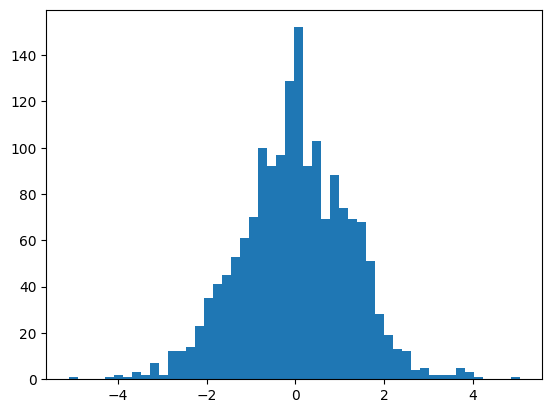

In [30]:
plt.hist(zspread_rolling,bins = 50)

This Z spread looks more normally distributed than Static SLR Z score, which means our residuals are more normally distributed

## **Kalman Filter**

We will now predict $\mu$ and $\beta$ using kalman filter. Note that theory of kalman filter is there in notes with all the formulas.



We are trying to predict 3 states i.e distance, speed and acceleration where acceleration will be constant since it is a constant velocity model. All the 3 states are projected across X axis. We will use the formulas that we saw in multidimensional Kalman Filter.

**State Prediction**

1. **Predict the state:**

$$
\hat{x}_{m+1|m} = F \hat{x}_{m|m}
$$

2. **Predict the covariance (prediction uncertainty):**

$$
\hat{P}_{m+1|m} = F P_{m|m} F^T + Q
$$

---

**State Update**

1. **Compute Kalman Gain:**

$$
K_m = P_{m|m-1} H^T
$$

2. **Update estimated state:**

$$
\hat{x}_{m|m} = \hat{x}_{m|m-1} + K_m \left( z_m - H \hat{x}_{m|m-1} \right)
$$

3. **Update estimation uncertainty:**

$$
P_{m|m} = (I - K_m H) P_{m|m-1} (I - K_m H)^T + K_m R K_m^T
$$

Our Base equation is
$
y_{1t} = \mu + \beta y_{2t} + \varepsilon_t$
and we have to predict two states therefore $\hat(x)$ will be a matrix of 2 * 1

In [31]:
def state_prediction(F,x_prev):
  state_predicted = np.dot(F,x_prev)
  return state_predicted

def variance_prediction(F,initial_P,Q):
  variance_predicted = np.dot(F,np.dot(initial_P,F.T)) + Q
  return variance_predicted

def kalman_gain(H,variance_predicted,R):
  #km = np.dot(np.dot(variance_predicted,H.T), np.linalg.inv(np.dot(H,np.dot(variance_predicted,H.T)) + R))
  #for computational effeciency and since the part after linalg is a scalar 1 by 1 number we will write our code as below
  S = np.dot(H,np.dot(variance_predicted,H.T)) + R
  S = S.item()  # ensure S is scalar value and not 1by1 array
  km = np.dot(variance_predicted,H.T) / S #efficient scalar divison
  return km

def state_updated(state_predicted,H,kalman_gain,z):
  x_n = state_predicted + np.dot(kalman_gain, (z - np.dot(H,state_predicted)))
  return x_n

def variance_updated(variance_predicted,kalman_gain,H):
  I = np.eye(2) #2 by 2 identity matrix
  P_n = np.dot((I - np.dot(kalman_gain,H)),variance_predicted)
  return P_n

We have realized that Value of Q and R plays a big role in our trading results, we took very small Q and R initially, now taking small Q means our kalman filter was smoother than it should have been. To get best results for Q and R we have to do grid search or use other statistical methods.

Q (Process Noise): This represents the uncertainty in your model's state. In your case, the state is the [mu, beta] relationship.
A low Q tells the filter: "I believe the true mu and beta are very stable and don't change much day-to-day." The filter will be slow to update its estimates.
A high Q tells the filter: "I believe the true mu and beta relationship is noisy and can change quickly." This makes the filter more adaptive and quicker to adjust its estimates based on new price data.

R (Measurement Noise): This represents the uncertainty or noise in your measurement. Your measurement is the actual observed stock price (e.g., Infosys).
A low R tells the filter: "I trust the daily closing price completely. It is a perfect reflection of the underlying relationship." The filter will closely follow every price movement.
A high R tells the filter: "The daily closing price is very noisy and not a reliable indicator of the true relationship. Don't overreact to it." This makes the filter smoother and less sensitive to daily volatility.

In [84]:
#Defining our initial values
#F represents state transition matrix and is used in state and variance Prediction, according to our equation F is given by
F = np.array([[1,0],[0,1]])
#Q measures process noise that is how much our mu and beta might vary, if we take very large our values will jump around a lot
#Most papers take this as static number only but they can be later replaced by some dynamic numbers as they are vol of mu and vol of Beta
Q = np.array([[100,0],[0,100]])
#R measures our measurement noise, for simplicity we have taken R as 1, we can tune this during backtesting
R = 10
#initial values
x_initial = np.array([0.0,1.0])
p_initial = np.eye(2)*2


In [33]:
def kalman_estimation(infosys_price,tcs_price,x,F,p,Q,R):
  mus = []
  betas = []
  residuals = []
  n = len(infosys_price)

  for t in range(n):
    z = infosys_price.iloc[t]
    tcs_t = tcs_price.iloc[t]
    #H Matrix which tells us how many states we want to estimate * how many states we can measure. Here our base essence is that we are trying to predict Infosys price on TCS
    #Therefore for the measurement state we will take price of TCS only
    H = np.array([1,tcs_t])

    #Predict the state, the first x will be initial x value
    x = state_prediction(F,x)

    #predicting the prediction Var
    p = variance_prediction(F,p,Q)

    #kalman gain
    Kn = kalman_gain(H,p,R)

    #state update
    x = state_updated(x,H,Kn,z)

    #Variance Update
    p = variance_updated(p,Kn,H)

    mus.append(x[0])
    betas.append(x[1])
    prediction = x[0] + x[1]*tcs_t
    residuals.append(z - prediction)


  return {'mus': np.array(mus),'betas': np.array(betas),'residuals':np.array(residuals)}







In [34]:
results_kalman = kalman_estimation(df1['Infosys'],df1['TCS'],x_initial,F,p_initial,Q,R)


In [35]:
zspread_kalman = calculate_zspreads(results_kalman['residuals'])


In [36]:
print('Mean:', np.mean(results_kalman['residuals']))
print('Std:', np.std(results_kalman['residuals']))
print('Min:', np.min(results_kalman['residuals']))
print('Max:', np.max(results_kalman['residuals']))

Mean: -3.084756489427671e-07
Std: 1.2727623205270797e-05
Min: -0.0005289032784503434
Max: 1.5934260204630846e-06


(array([  2.,   0.,   0.,   0.,   0.,   0.,   3.,   0.,   0.,   0.,   1.,
          1.,   0.,   1.,   0.,   5.,   7.,   5.,  14.,  21.,  27.,  49.,
         73.,  90., 122., 164., 196., 248., 158., 132., 128.,  94.,  67.,
         45.,  22.,  16.,  10.,   5.,   5.,   5.,   2.,   1.,   1.,   1.,
          1.,   2.,   0.,   1.,   0.,   1.]),
 array([-5.91519189, -5.69877116, -5.48235044, -5.26592972, -5.04950899,
        -4.83308827, -4.61666755, -4.40024682, -4.1838261 , -3.96740538,
        -3.75098465, -3.53456393, -3.31814321, -3.10172249, -2.88530176,
        -2.66888104, -2.45246032, -2.23603959, -2.01961887, -1.80319815,
        -1.58677742, -1.3703567 , -1.15393598, -0.93751525, -0.72109453,
        -0.50467381, -0.28825308, -0.07183236,  0.14458836,  0.36100909,
         0.57742981,  0.79385053,  1.01027126,  1.22669198,  1.4431127 ,
         1.65953343,  1.87595415,  2.09237487,  2.3087956 ,  2.52521632,
         2.74163704,  2.95805777,  3.17447849,  3.39089921,  3.60731994,
 

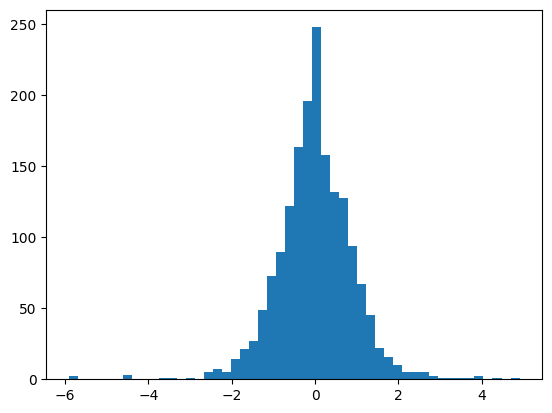

In [37]:
plt.hist(zspread_kalman,bins = 50)

This Z spread is highly centered around 0 and very less deviations on +/-2 which means we will have the least amount of signals generated here

## **Comparing all 3 models**

We will now compare all 3 models based on predictions and then finally backtest all the strategies to show which one is the best

Checking Beta movement over time

Static SLR Beta is 0.5062243189327518


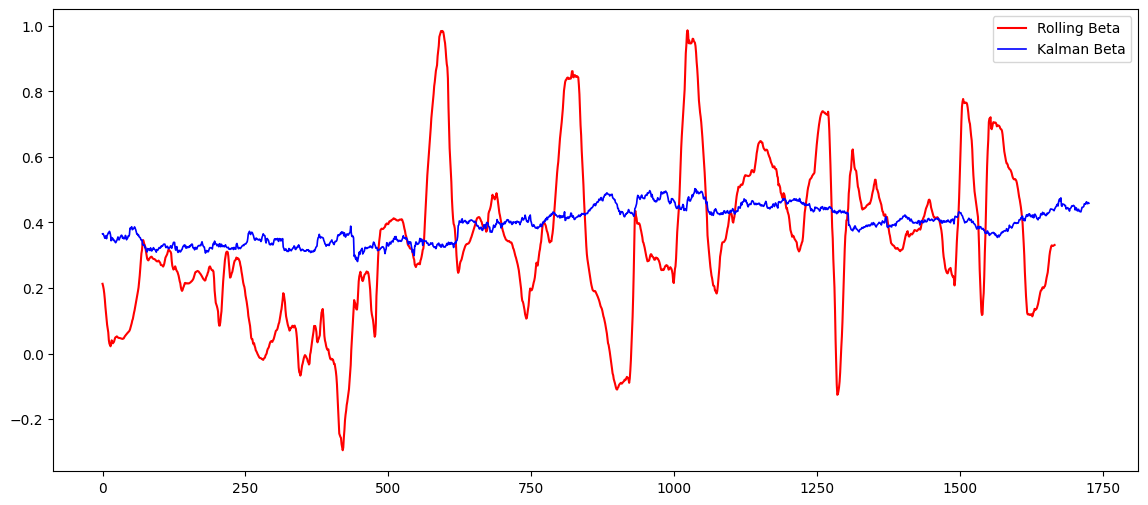

In [38]:
#Visually let's check how the betas move over time
plt.figure(figsize=(14,6))
print('Static SLR Beta is',beta_SLR)
plt.plot(results['betas'],color = 'red',lw =1.5,label = "Rolling Beta")
plt.plot(results_kalman['betas'],color = 'blue', lw =1.2, label = 'Kalman Beta')
plt.plot()
plt.legend()
plt.show()

Static SLR Beta is -278.47967316204654


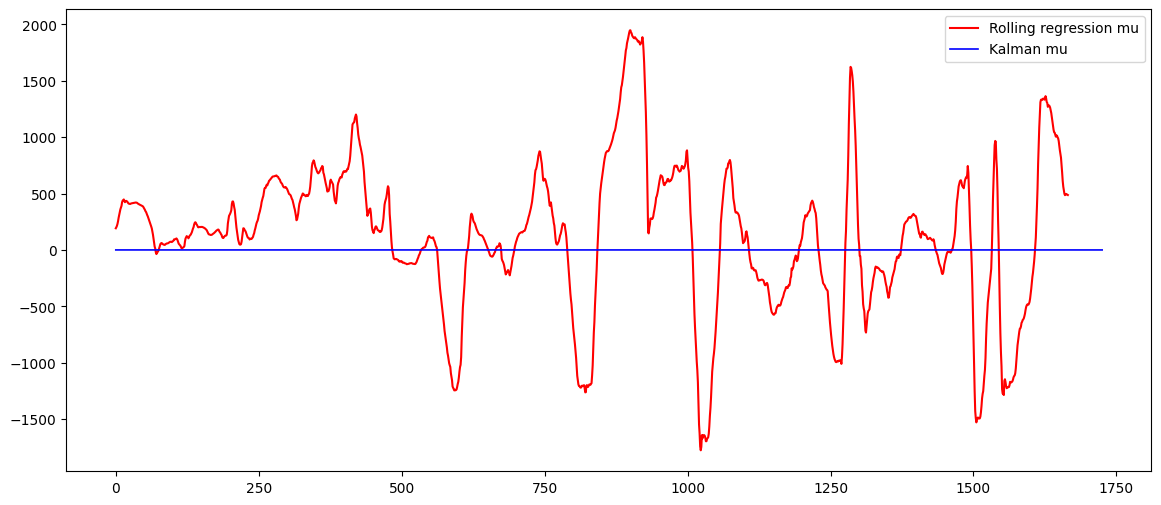

In [39]:
print('Static SLR Beta is',mu_SLR)
plt.figure(figsize=(14,6))
plt.plot(results['mus'],color = 'red',lw =1.5,label = "Rolling regression mu")
plt.plot(results_kalman['mus'],color = 'blue', lw =1.2, label = 'Kalman mu')
plt.legend()
plt.show()

From above we can see that both our betas and mu are very adaptive in Rolling regression whereas they are very smooth in kalman filter

## Trading Strategy

We will trade based on our Z values, When Z value is positive that means residual is positive, which implies that infosys market price is expensive from what we estimated using TCS therefore we sell infosys and Buy TCS and vice versa.

When Z > 2 : sell infosys, buy TCS
when Z <-2 : Buy infosys, sell TCA
exit when |Z| <0.5 i.e the spread has normalized

In [40]:
def generate_signals(z_scores,entry =2.0, exit = 0.5):

  #Our initial positions are 0, the positions array show our actual position held till we go back to 0, we can continue to hold long spread for days before returning back
  #whereas signal is just a switch
  positions = np.zeros(len(z_scores))
  position = 0
  for i in range(len(z_scores)):
    if position == 0: #not in any trade look for entry
      if z_scores[i] > entry:
        position = -1 #Short the spred that is short infosys and long TCS
      elif z_scores[i] < -entry:
        position = 1 #Long spread that is buy Infosys and Sell TCS

    elif position == -1: #already short position
      if z_scores[i] < exit:
        position = 0 #exit short

    elif position == 1:
      if z_scores[i] > -exit:
        position = 0 #exit long

    positions[i] = position

  return positions



In [41]:
def backtest_pairs_strategy(price_infosys,price_tcs,positions,betas,transaction_cost = 0.001):

  #Calculating Infosys returns
  returns_Infosys = price_infosys.pct_change().fillna(0)

  #calculating TCS returns
  returns_TCS = price_tcs.pct_change().fillna(0)

  positions = np.asarray(positions) #converting everything to numpy array as we were having some error while trying to calculate numpy array and pd series together

  if isinstance(betas, (pd.Series, pd.DataFrame)):
    betas = betas.values # Convert pandas Series/DataFrame to numpy array

  #Positions for infosys, the sign of the positions will the same as spread, i.e if we are long the spread we are long infosys and if we are short spread we are short infosys
  #We are not taking the last value here because we want to align this in a way that if we have the signal or +1 or -1 today we will act on in tomorrow
  positions_Infosys = positions[:-1]

  #positions for TCS will be oppsite of spread i.e if we are short the spread that means we are long TCS
  #Also here we are aligning it in a way that we use today's signal and act on it tomorrow
  #Positions for TCS will be hedged positions using our hedge ratio so that you remain market neutral
  if np.isscalar(betas):
    betas = np.full_like(positions, betas, dtype=float) #To convert scalar beta value to an array mainly used for simple linear regression
  positions_TCS = -positions[:-1] * betas[:-1]

  #Below we will align i.e yesterday's signal based on which we took entry today morning therefore we will have the returns of today
  #The P&L you get below is P&L % and not the absolute number since we are multiplying returns with the spread
  pnl = (positions_Infosys * returns_Infosys[1:] + positions_TCS * returns_TCS[1:])

  # Transaction cost: Only when position changes (entry/flip/exit)
  trade_flag = np.abs(np.diff(positions))  # 1 when position changes, else 0
  trans_cost = trade_flag * transaction_cost

  pnl = pnl - trans_cost

  equity_curve = np.cumsum(pnl) #This is cumulative returns
  return pnl, equity_curve


For SLR we will be using in sample data only, this might lead to a bit skewed results but we wanted a longer time frame to see how our strategy is performing. We might get a better result here than other strategies becuase the other strategies are pedicting on rolling basis

In [42]:
positions_SLR = generate_signals(zspread_SLR)
pnl_SLR, equity_curve_SLR = backtest_pairs_strategy(df1['Infosys'],df1['TCS'],positions_SLR,beta_SLR)

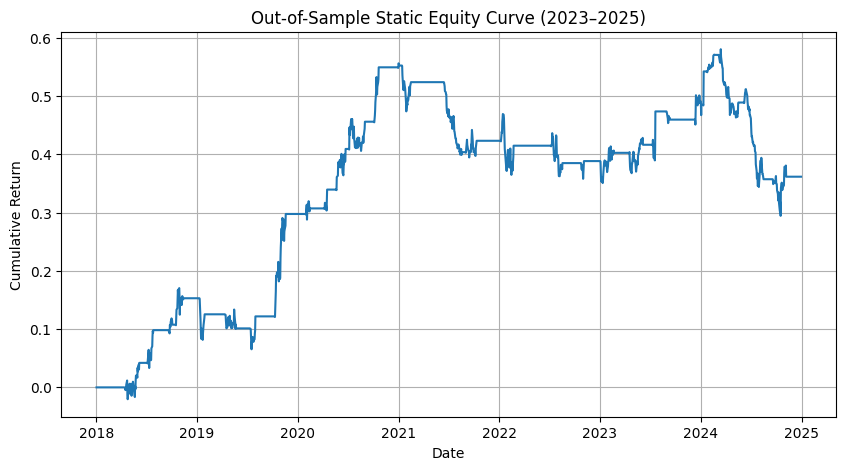

In [43]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(equity_curve_SLR)
plt.title("Out-of-Sample Static Equity Curve (2023–2025)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

Our cumulative returns in SLR was good mainly because we have incorporated look ahead bias and calculated both our beta and mu on the future data, we should see our results dropping in rolling regression as well as in kalman filter

In [44]:
#Since the z spread and all the values for rolling regression starts from 60th index we have taken all the values in a similar fashion
positions_rolling = generate_signals(zspread_rolling)
pnl_rolling, equity_curve_rolling = backtest_pairs_strategy(df1['Infosys'].iloc[60:],df1['TCS'].iloc[60:],positions_rolling,results['betas'])


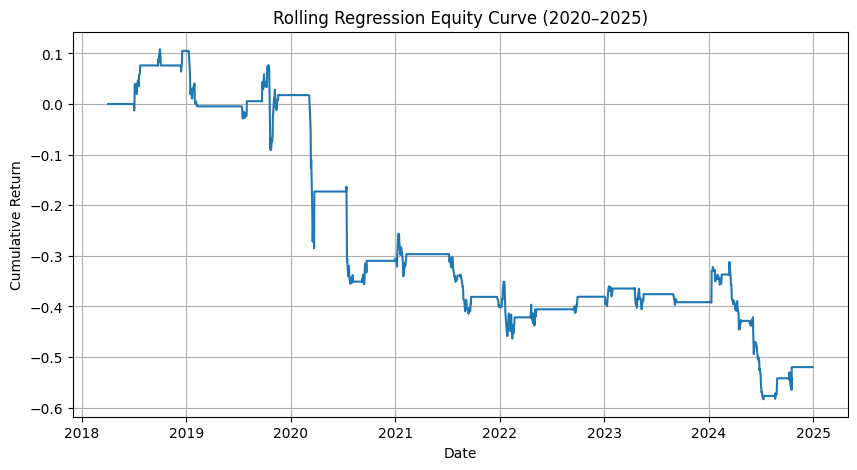

In [45]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(equity_curve_rolling)
plt.title("Rolling Regression Equity Curve (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

In [46]:
positions_kalman = generate_signals(zspread_kalman)
pnl_kalman, equity_curve_kalman = backtest_pairs_strategy(df1['Infosys'],df1['TCS'],positions_kalman,results_kalman['betas'])

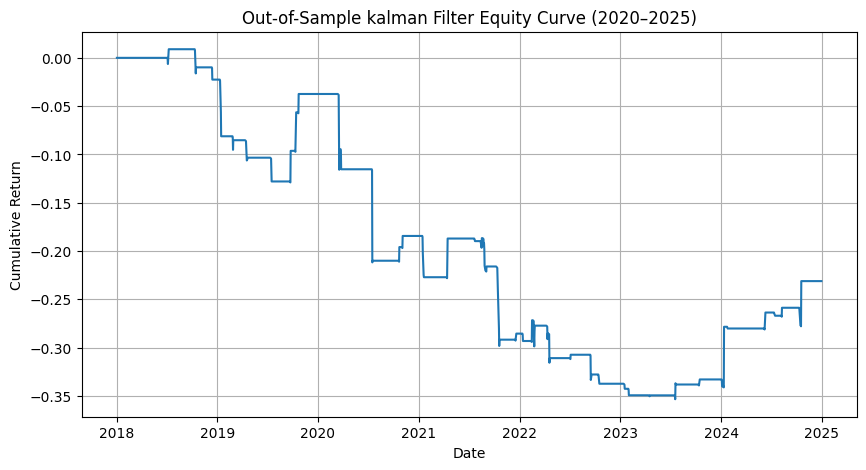

In [47]:
plt.figure(figsize=(10, 5))
plt.plot(equity_curve_kalman)
plt.title("Out-of-Sample kalman Filter Equity Curve (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

We saw that only SLR gave us positive returns and that was because we had look ahead bias there, both kalman filter and rolling regression gave us negative returns confirming that this is not a good pair to trade. Let us try one pair from banking sector

# **Pairs Trading Strategy ( Bank pair )**

We will now take a banking pair to see if we can get a positive returns from our pair trading strategy


## General Data

In [48]:
start = '2018-01-01'
end = '2024-12-31'

hdfc = yf.download("HDFCBANK.NS",start = start, end = end)['Close']
icici = yf.download("ICICIBANK.NS",start = start, end = end)['Close']

df_bank = pd.concat([hdfc,icici],axis = 1).dropna()
df_bank.columns = ['HDFC','ICICI']
df_bank

/tmp/ipython-input-160901457.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hdfc = yf.download("HDFCBANK.NS",start = start, end = end)['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-160901457.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  icici = yf.download("ICICIBANK.NS",start = start, end = end)['Close']
[*********************100%***********************]  1 of 1 completed


,HDFC,ICICI
Date,,
2018-01-01,869.462280,300.354797
2018-01-02,877.831055,299.774048
2018-01-03,868.594971,304.904236
2018-01-04,871.994019,304.613831
2018-01-05,873.728760,302.871490
...,...,...
2024-12-23,1781.402710,1296.800049
2024-12-24,1778.534180,1297.250000
2024-12-26,1771.264160,1297.349976


In [49]:
X = sm.add_constant(df_bank['HDFC'])
#Using OLS for regression we get
model = sm.OLS(df_bank['ICICI'],X).fit()

print(model.summary())

df_bank['Residuals'] = model.resid

                            OLS Regression Results                            
Dep. Variable:                  ICICI   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     8447.
Date:                Wed, 06 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:33:12   Log-Likelihood:                -10753.
No. Observations:                1726   AIC:                         2.151e+04
Df Residuals:                    1724   BIC:                         2.152e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -709.7745     15.208    -46.672      0.0

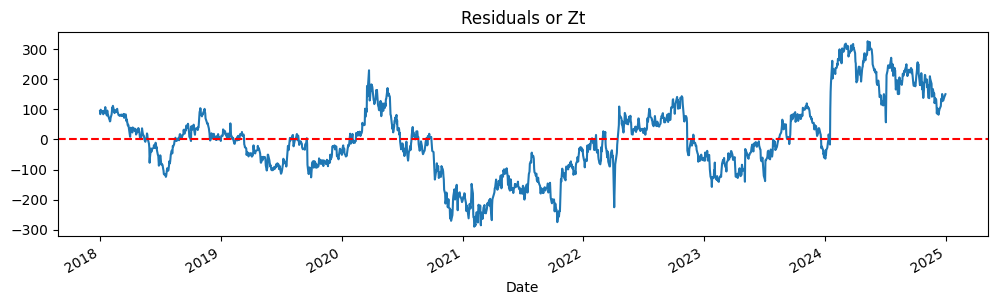

In [50]:
df_bank['Residuals'].plot(figsize=(12,3), title = 'Residuals or Zt')
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [51]:
adf_result = adfuller(df_bank['Residuals'])
print('p_value',adf_result[1])

p_value 0.04708640405027825


Let's try to take the opposite pair and see the results

In [52]:
X = sm.add_constant(df_bank['ICICI'])
#Using OLS for regression we get
model = sm.OLS(df_bank['HDFC'],X).fit()

print(model.summary())

df_bank['Residuals'] = model.resid

                            OLS Regression Results                            
Dep. Variable:                   HDFC   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     8447.
Date:                Wed, 06 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:33:12   Log-Likelihood:                -10502.
No. Observations:                1726   AIC:                         2.101e+04
Df Residuals:                    1724   BIC:                         2.102e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        779.7442      6.219    125.373      0.0

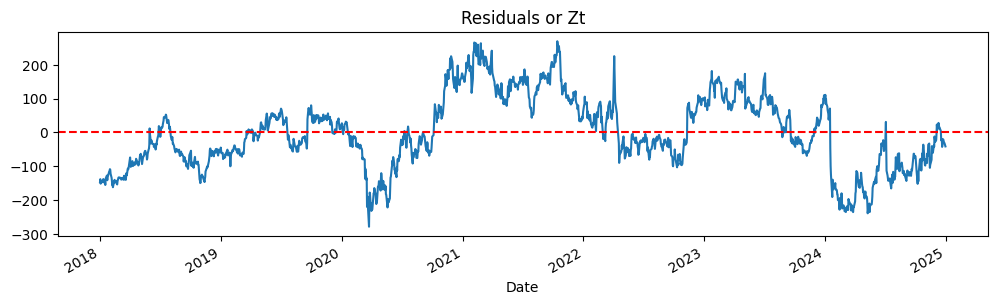

In [53]:
df_bank['Residuals'].plot(figsize=(12,3), title = 'Residuals or Zt')
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [54]:
adf_result = adfuller(df_bank['Residuals'])
print('p_value',adf_result[1])

p_value 0.010792046789818538


The P value of HDFC depending on ICICI is less that means this pair is more cointegrated, hence we will move forward with this pair i.e X = ICICI and Y = HDFC

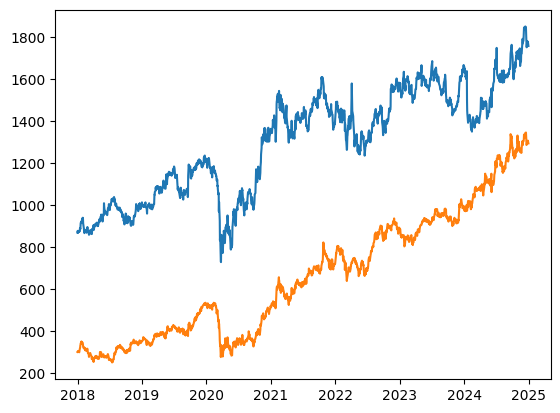

In [55]:
plt.plot(df_bank['HDFC'])
plt.plot(df_bank['ICICI'])

## SLR
Trying the SLR first

In [56]:
x,y,mu_SLR, beta_SLR , residuals_SLR, model_SLR = static_linear_regression(df_bank['HDFC'],df_bank['ICICI'])
print(f'The Average price difference is: {mu_SLR:.2f}')
print(f'The hedge ratio is: {beta_SLR:.4f} (how much Infosys depends on TCS)')
residuals_SLR

The Average price difference is: 779.74
The hedge ratio is: 0.7879 (how much Infosys depends on TCS)


array([-146.94430078, -138.11792904, -151.39630708, ...,  -30.71747053,
        -31.33608652,  -41.30014678])

In [57]:
zspread_SLR = calculate_zspreads(residuals_SLR)
zspread_SLR

,0
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
...,...
1721,0.797398
1722,0.707478
1723,0.526424
1724,0.497834


In [58]:
positions_SLR = generate_signals(zspread_SLR)
pnl_SLR, equity_curve_SLR = backtest_pairs_strategy(df_bank['HDFC'],df_bank['ICICI'],positions_SLR,beta_SLR)

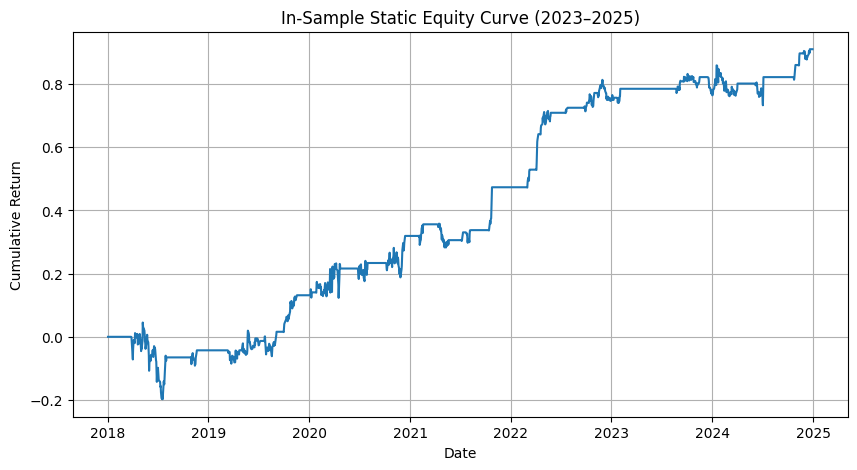

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(equity_curve_SLR)
plt.title("In-Sample Static Equity Curve (2023–2025)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

##Rolling Regression
Let's Now see the results with rolling regression

In [60]:
results = rolling_regression_proper(df_bank['HDFC'],df_bank['ICICI'])
zspread_rolling = calculate_zspreads(results['residuals'])

positions_rolling = generate_signals(zspread_rolling)
pnl_rolling, equity_curve_rolling = backtest_pairs_strategy(df_bank['HDFC'].iloc[60:],df_bank['ICICI'].iloc[60:],positions_rolling,results['betas'])

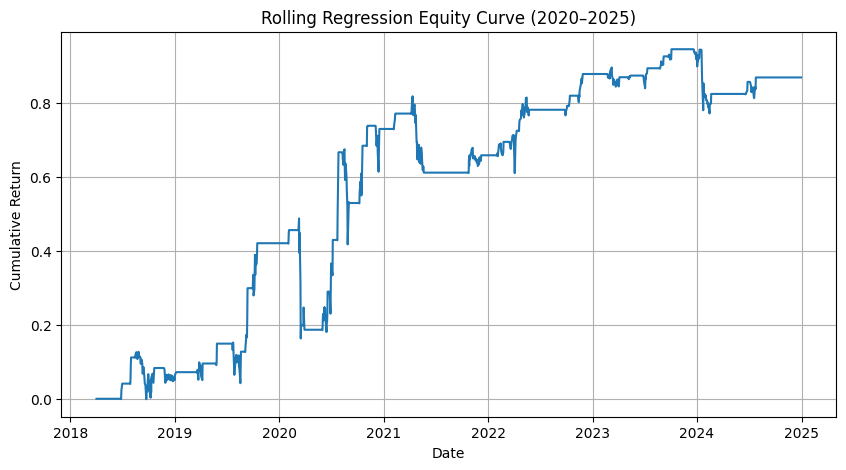

In [61]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(equity_curve_rolling)
plt.title("Rolling Regression Equity Curve (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

## Kalman Filter

In [62]:
#sigma_mu = results['mus'].std()
#sigma_beta = results['betas'].std()
#sigma_resids = results['residuals'].std()

#Q = np.array([[sigma_mu,0],[0,sigma_beta]])
#R = sigma_resids

In [85]:
results_kalman = kalman_estimation(df_bank['HDFC'],df_bank['ICICI'],x_initial,F,p_initial,Q,R)
zspread_kalman = calculate_zspreads(results_kalman['residuals'])


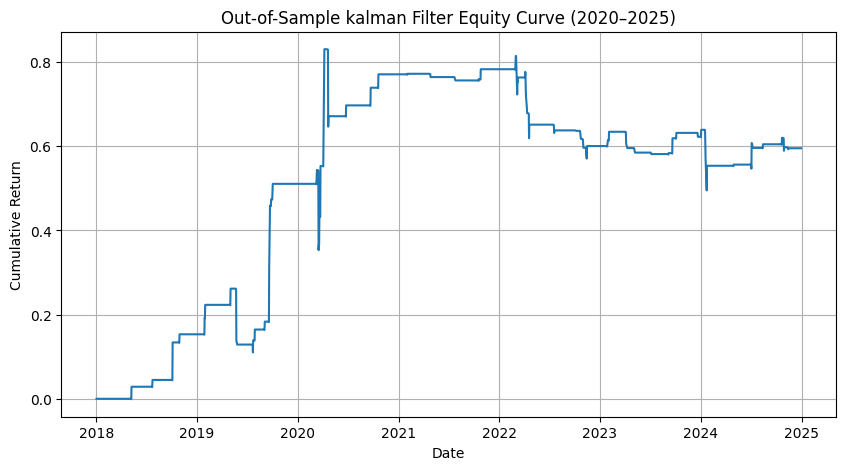

In [86]:
positions_kalman = generate_signals(zspread_kalman)
pnl_kalman, equity_curve_kalman = backtest_pairs_strategy(df_bank['HDFC'],df_bank['ICICI'],positions_kalman,results_kalman['betas'])

plt.figure(figsize=(10, 5))
plt.plot(equity_curve_kalman)
plt.title("Out-of-Sample kalman Filter Equity Curve (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()


Overall we can see that Rolling regression gave us highest returns over the period of 5 years. The banking pair has performed much better as compared to the IT pair. To get better results in terms of kalman we had to tweek Q and R to different values. In future we have to think of more robust ways to select Q and R.

Let us see the Max drawdown and sharpe ratio of our strategies

In [70]:
equity_curve_kalman.min()

-0.001

In [90]:
def calculate_sharpe(pnl):

  pnl = np.array(pnl) #ensuring daily pnl is numpy array
  daily_pnl_avg = np.average(pnl)
  daily_pnl_std = np.std(pnl)

  #Annualized returns and std
  annualized_pnl = daily_pnl_avg *252
  annualized_std = daily_pnl_std * np.sqrt(252)

  sharpe_ratio = (annualized_pnl - 0.04) / annualized_std #0.04 we have taken

  return sharpe_ratio

In [101]:
sharpe_rolling = calculate_sharpe(pnl_rolling)
sharpe_rolling

np.float64(0.4033122039943607)

In [92]:
sharpe_kalman = calculate_sharpe(pnl_kalman)
sharpe_kalman

np.float64(0.23210714299507224)

This ideally shows us that simplicity can win and not always the most complex strategies get us the best results. We can obviously improve our kalman filter by parameter optimization but our goal here was to simply see how we can use kalman filter to discover latent features